# Rollout regenerate comparison: `runs_infer_adj_msg`

Compare rollout regeneration ability across runs in `runs_infer_adj_msg/`.

Runs vary along three axes:
- **adj_type** (inferred Aij from co-runs): `runs3thr0p6`, `runs5thr0p5`, `runs5thr0p6`
- **msg_config**: `rate2`, `rate_x`, `rate_ma`
- **seed**: 1..5

For each run we load the trained model + its `fixed_adjacency.npy`, give it a single initial value, do an autoregressive rollout, and compare against the ground-truth trajectory on the test split (and train split).

Rollout helper functions are reused from `compare_rollout_msg_lam0.001_only.ipynb`.

In [1]:
import os, sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from statsmodels.tsa.seasonal import seasonal_decompose


def resolve_ablation_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / 'Hungarianchickenpox' / 'datalimits4dyn_nozscore',
    ]
    for candidate in candidates:
        if (candidate / 'runs_infer_adj_msg').exists():
            return candidate
    raise FileNotFoundError('Could not locate Hungarianchickenpox/datalimits4dyn_nozscore from the current working directory.')


ABLATION_DIR = resolve_ablation_dir()
PROJECT_DIR = ABLATION_DIR.parent
RUNS_DIR = ABLATION_DIR / 'runs_infer_adj_msg'

sys.path.insert(0, str(ABLATION_DIR))
from model_ablation_msg import build_fully_connected_edge_index, FULL_SELF_INDICES
from model_fixed_adj_ablation_msg import GraphDerivNNFixedAdjMsgAblation

device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
print('ABLATION_DIR:', ABLATION_DIR)
print('PROJECT_DIR:', PROJECT_DIR)
print('RUNS_DIR:', RUNS_DIR)
print('Device:', device)


ABLATION_DIR: /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox/datalimits4dyn_nozscore
PROJECT_DIR: /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox
RUNS_DIR: /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox/datalimits4dyn_nozscore/runs_infer_adj_msg
Device: cuda:2


In [2]:
ADJ_TYPES = ['runs3thr0p6']
MSG_CONFIGS_LIST = ['rate_x']
SEEDS = [1, 2, 3, 4, 5]
ZSCORE_TAG = 'nozscore'
SMOOTH_TAG = 'gaussian'

def run_dir_for(seed, adj_type, msg_config):
    return RUNS_DIR / f'run{seed}_{adj_type}_{msg_config}_{ZSCORE_TAG}_{SMOOTH_TAG}'

missing = []
for adj in ADJ_TYPES:
    for msg in MSG_CONFIGS_LIST:
        for s in SEEDS:
            d = run_dir_for(s, adj, msg)
            if not d.is_dir():
                missing.append(str(d))
print(f'{len(ADJ_TYPES)*len(MSG_CONFIGS_LIST)*len(SEEDS)} total combos, {len(missing)} missing')
for d in missing[:10]:
    print(' missing:', d)


5 total combos, 0 missing


In [3]:
# Load and preprocess data (mirror of compare_rollout_msg_lam0.001_only.ipynb)
ts = pd.read_csv(PROJECT_DIR / 'hungary_chickenpox_reordered_trimmed.csv')
county_names = list(ts.columns[1:])
X_raw = ts.iloc[:, 1:].to_numpy(dtype=np.float32)
X_smooth = gaussian_filter1d(X_raw, sigma=1.5, axis=0, mode='nearest')
T_raw, N = X_smooth.shape

seasonal_full = np.zeros_like(X_smooth, dtype=np.float32)
for n in range(N):
    res = seasonal_decompose(X_smooth[:, n], model='additive', period=52, extrapolate_trend='freq')
    seasonal_full[:, n] = res.seasonal.astype(np.float32)

T_eff = T_raw - 12
n_train = int(T_eff * 0.6)
n_val = int(T_eff * 0.2)
n_test = T_eff - n_train - n_val

t_train_start_raw = 11
t_test_start_raw = 11 + n_train + n_val
edge_index = build_fully_connected_edge_index(N)

print(f'T_raw={T_raw}, N={N}, train={n_train}, val={n_val}, test={n_test}')
print(f'test starts at raw idx {t_test_start_raw}')

T_raw=485, N=20, train=283, val=94, test=96
test starts at raw idx 388


In [4]:
# Feature + rollout helpers (copied from compare_rollout_msg_lam0.001_only.ipynb)
def compute_features_at_t(X_history, t, seasonal_full):
    x_t = X_history[t]
    x_tm1 = X_history[t - 1] if t >= 1 else X_history[0]
    start = max(0, t - 2)
    ma3 = X_history[start:t + 1].mean(axis=0)
    prev3 = max(0, t - 3)
    diff3 = X_history[prev3] - X_history[t]
    T_orig = seasonal_full.shape[0]
    t_mod = min(t, T_orig - 1)
    t_mod_11 = min(max(t - 11, 0), T_orig - 1)
    seasonal_t = seasonal_full[t_mod]
    seasonal_rate = (seasonal_full[t_mod] - seasonal_full[t_mod_11]) / 11.0
    start5 = max(0, t - 4); ma5 = X_history[start5:t + 1].mean(axis=0)
    start10 = max(0, t - 9); ma10 = X_history[start10:t + 1].mean(axis=0)
    prev5 = max(0, t - 5); rate5 = (X_history[prev5] - X_history[t]) / 5.0
    prev10 = max(0, t - 10); rate10 = (X_history[prev10] - X_history[t]) / 10.0
    feats = np.stack([x_t, x_tm1, ma3, diff3, seasonal_t, seasonal_rate,
                      ma5, ma10, rate5, rate10], axis=1)
    return feats.astype(np.float32)

def rollout_predict(model, X_smooth_full, seasonal_full, t_start, n_steps,
                    edge_index, device, norm_stats=None):
    model.eval()
    T, N = X_smooth_full.shape
    X_history = X_smooth_full[:t_start + 1].copy()
    X_pred_list, X_true_list = [], []
    edge_index_dev = edge_index.to(device)
    with torch.no_grad():
        for step in range(n_steps):
            t_curr = t_start + step
            if t_curr + 1 >= T: break
            features = compute_features_at_t(X_history, t_curr, seasonal_full)
            if norm_stats is not None:
                x_mu, x_std = norm_stats['x_mu'], norm_stats['x_std']
                if x_mu.ndim == 3: x_mu, x_std = x_mu[0], x_std[0]
                features = (features - x_mu) / x_std
            x_tensor = torch.tensor(features, dtype=torch.float32).to(device)
            dxdt_pred = model(x_tensor, edge_index=edge_index_dev).cpu().numpy()
            if norm_stats is not None:
                y_mu, y_std = norm_stats['y_mu'], norm_stats['y_std']
                if y_mu.ndim == 3: y_mu, y_std = y_mu[0], y_std[0]
                dxdt_pred = dxdt_pred * y_std + y_mu
            x_next = X_history[t_curr] + dxdt_pred[:, 0] * 1.0
            X_pred_list.append(x_next)
            X_true_list.append(X_smooth_full[t_curr + 1])
            X_history = np.vstack([X_history, x_next.reshape(1, N)])
    return np.array(X_pred_list), np.array(X_true_list)

def compute_r2(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1); y_pred = np.asarray(y_pred).reshape(-1)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan

def compute_node_r2_mean(X_true, X_pred):
    return float(np.nanmean([compute_r2(X_true[:, i], X_pred[:, i]) for i in range(X_true.shape[1])]))

def load_norm_stats(run_dir):
    p = os.path.join(run_dir, 'norm_stats.pt')
    if not os.path.exists(p): return None
    stats = torch.load(p, map_location='cpu', weights_only=False)
    x_mu, x_std = stats['x_mu'].numpy(), stats['x_std'].numpy()
    y_mu, y_std = stats['y_mu'].numpy(), stats['y_std'].numpy()
    if np.allclose(x_mu, 0, atol=1e-5) and np.allclose(x_std, 1, atol=1e-5):
        return None
    return {'x_mu': x_mu, 'x_std': x_std, 'y_mu': y_mu, 'y_std': y_std}

def load_infer_adj_model(run_dir, msg_config, device):
    ckpt = torch.load(os.path.join(run_dir, 'best_model.pt'), map_location='cpu', weights_only=False)
    fixed_adj = np.load(os.path.join(run_dir, 'fixed_adjacency.npy'))
    model = GraphDerivNNFixedAdjMsgAblation(
        n_f=10, msg_dim=1, ndim=1, delt_t=1.0, num_nodes=N,
        fixed_adj=torch.tensor(fixed_adj, dtype=torch.float32),
        msg_config=msg_config, hidden=100, dropout=0.10,
    ).to(device)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()
    return model, load_norm_stats(run_dir), fixed_adj

print('Helpers ready.')

Helpers ready.


In [5]:
# Run rollout for every (adj_type, msg_config, seed). One initial value -> rollout to end of split.
horizons = [1, 5, 10, 20, 50, n_test]
all_rows = []
# Cache full-test trajectories of every run for trajectory plots
test_traj_cache = {}

for adj in ADJ_TYPES:
    for msg in MSG_CONFIGS_LIST:
        for seed in SEEDS:
            d = run_dir_for(seed, adj, msg)
            if not os.path.isdir(d): continue
            try:
                model, norm_stats, fixed_adj = load_infer_adj_model(d, msg, device)
            except Exception as e:
                print(f'  SKIP {adj}/{msg}/seed{seed}: {e}'); continue
            for split, t0, max_steps in [('test', t_test_start_raw, n_test),
                                          ('train', t_train_start_raw, n_train)]:
                for h in horizons:
                    steps = min(h, max_steps)
                    Xp, Xt = rollout_predict(model, X_smooth, seasonal_full, t0, steps,
                                              edge_index, device, norm_stats)
                    if len(Xp) == 0: continue
                    all_rows.append({
                        'adj_type': adj, 'msg_config': msg, 'seed': seed,
                        'split': split, 'horizon': steps,
                        'mse': float(np.mean((Xt - Xp) ** 2)),
                        'r2': compute_r2(Xt, Xp),
                        'node_r2_mean': compute_node_r2_mean(Xt, Xp),
                    })
                if split == 'test' and h == n_test:
                    test_traj_cache[(adj, msg, seed)] = (Xp.copy(), Xt.copy())
            del model; torch.cuda.empty_cache()
        print(f'  done {adj}/{msg}')
rollout_df = pd.DataFrame(all_rows)
out_csv = RUNS_DIR / 'rollout_infer_adj_msg_results.csv'
# rollout_df.to_csv(out_csv, index=False)
print(f'Saved {len(rollout_df)} rows -> {out_csv}')

/tmp/ipykernel_2917129/3394364480.py:57: RuntimeWarning: Mean of empty slice
  return float(np.nanmean([compute_r2(X_true[:, i], X_pred[:, i]) for i in range(X_true.shape[1])]))


  done runs3thr0p6/rate_x
Saved 60 rows -> /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox/datalimits4dyn_nozscore/runs_infer_adj_msg/rollout_infer_adj_msg_results.csv


## Test rollout R² vs horizon (mean ± std over seeds)
Rows = adj_type, columns = msg_config.

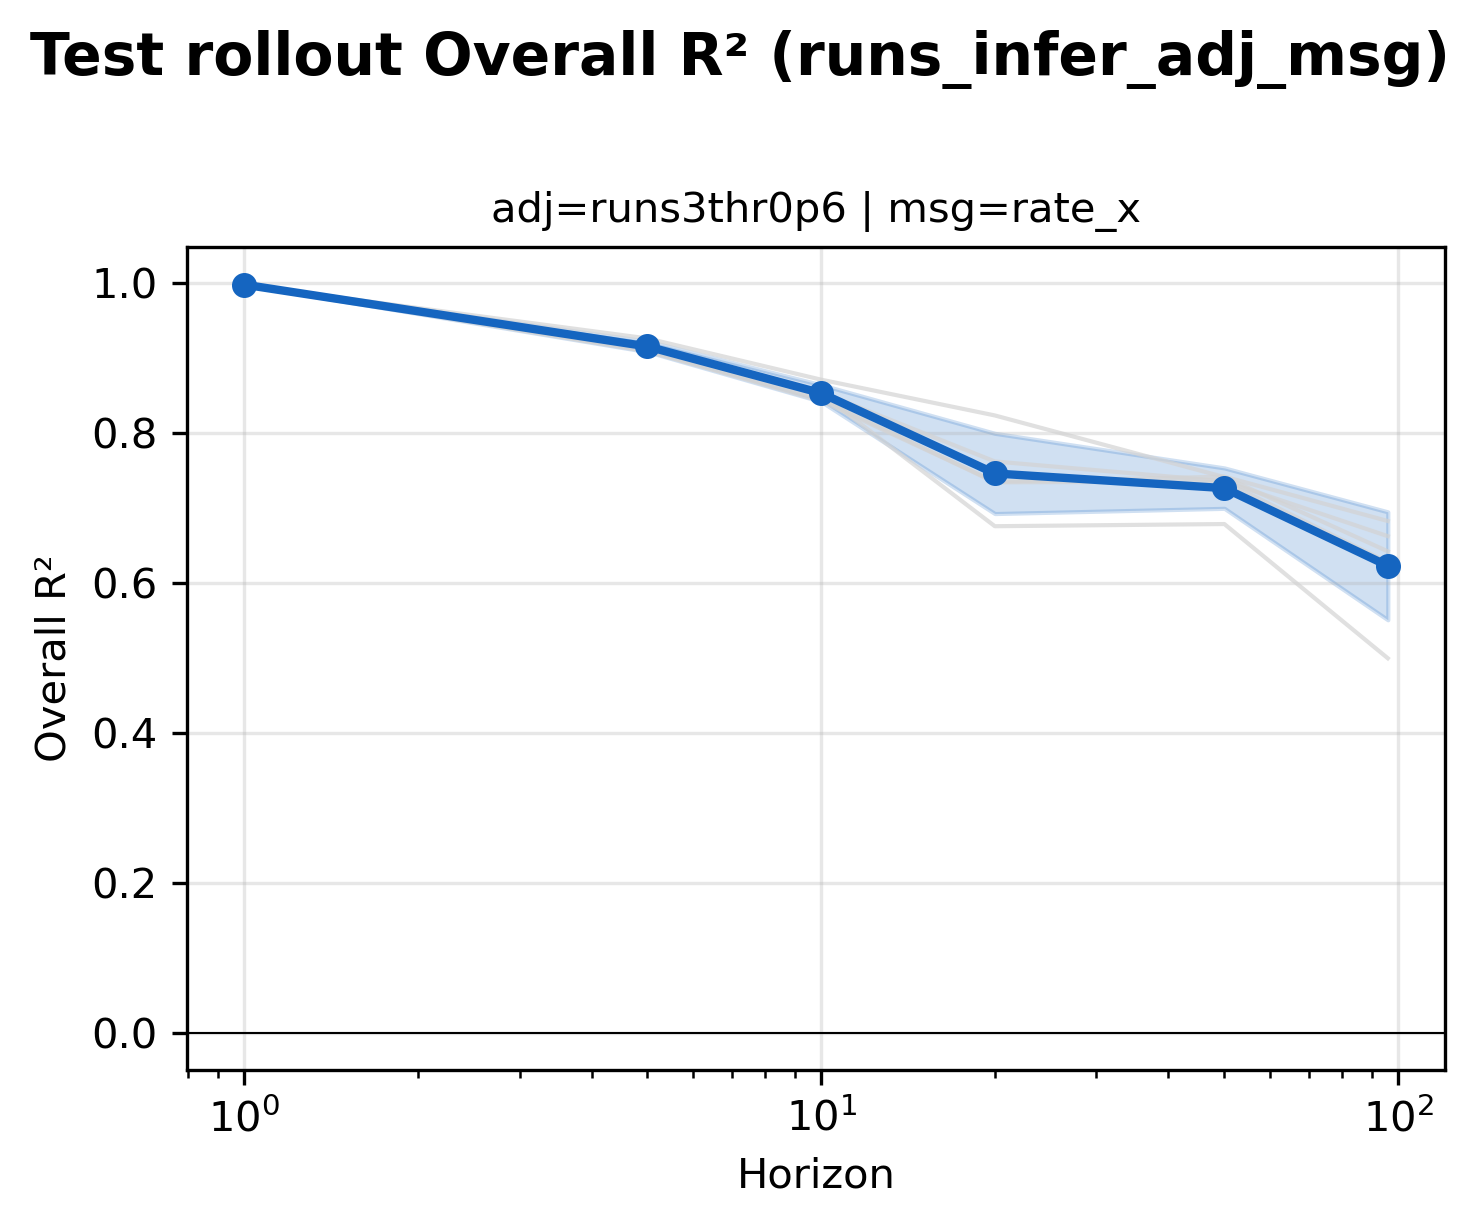

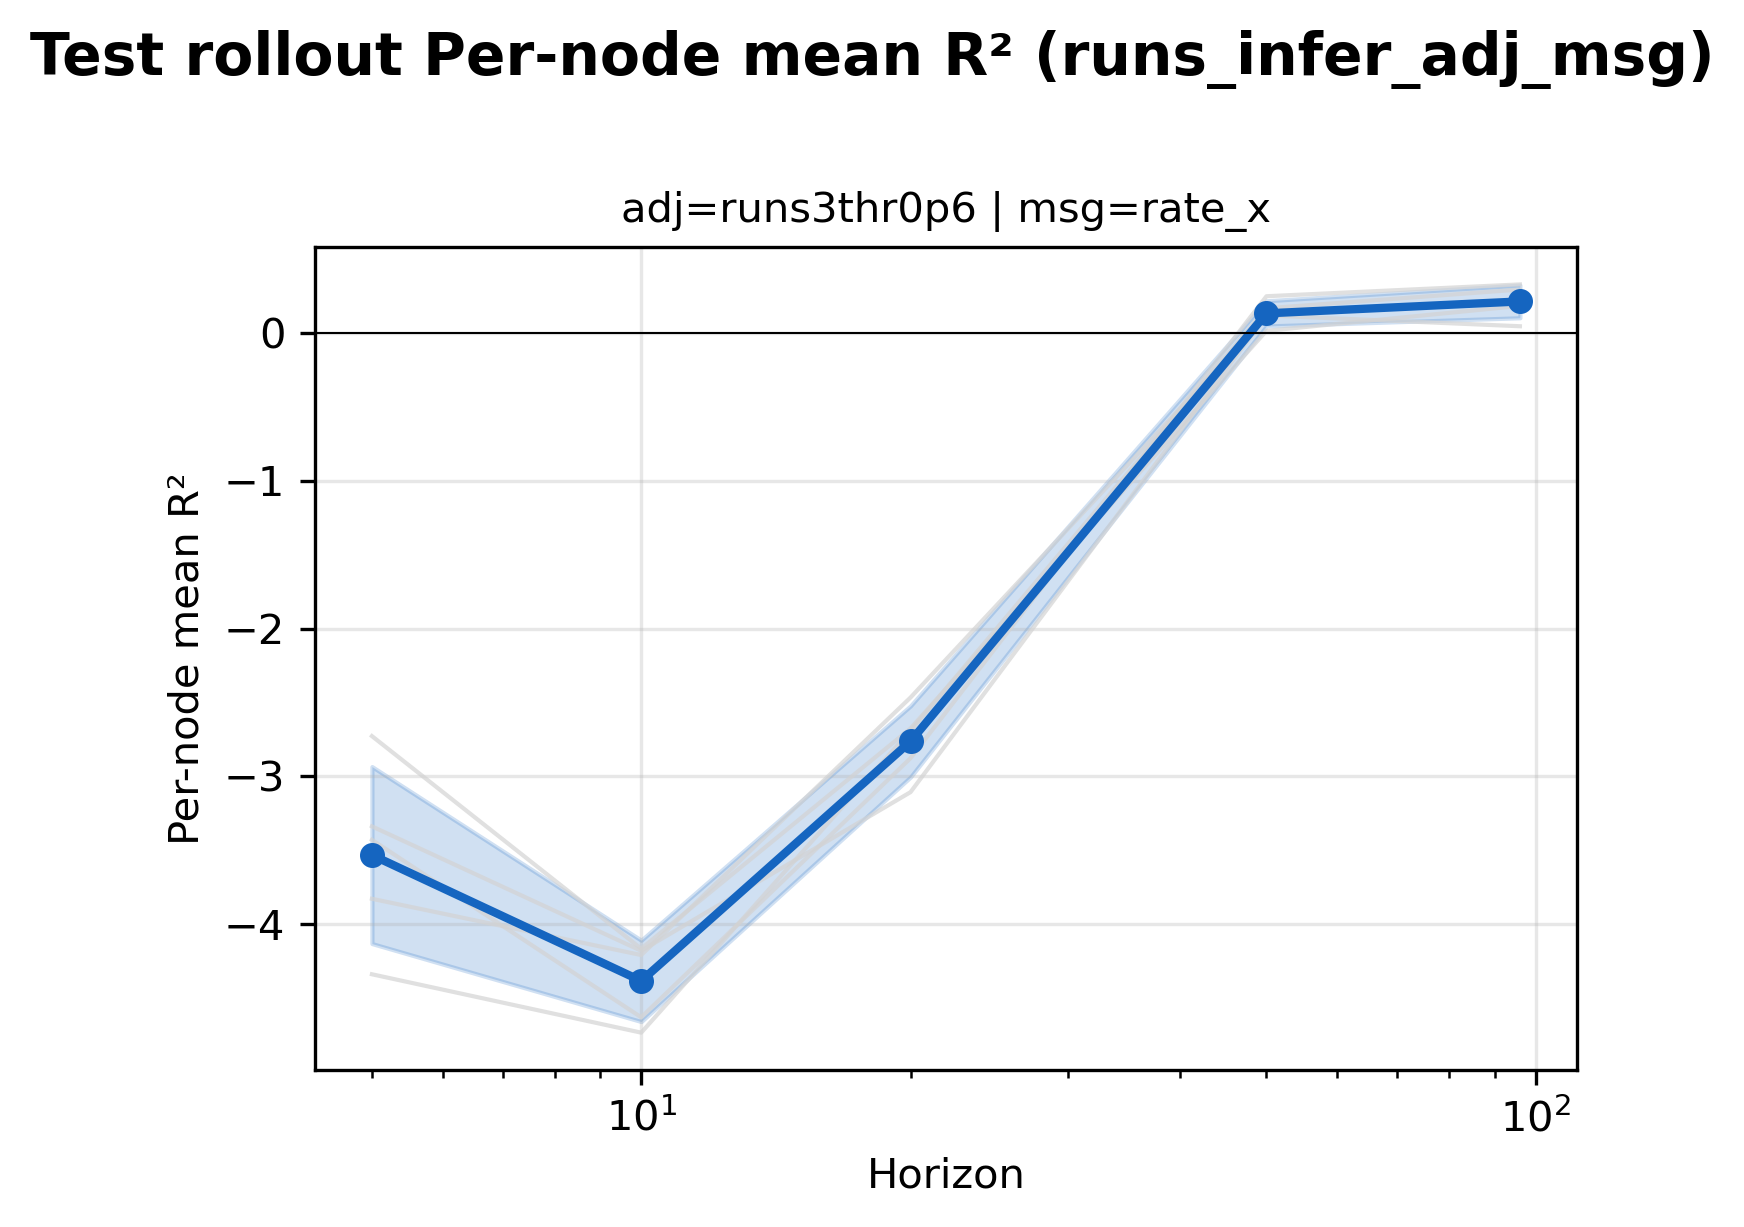

In [6]:
df_test = rollout_df[rollout_df['split'] == 'test'].copy()
for r2_col, r2_label, suffix in [('r2', 'Overall R²', 'overall'),
                                  ('node_r2_mean', 'Per-node mean R²', 'pernode')]:
    fig, axes = plt.subplots(len(ADJ_TYPES), len(MSG_CONFIGS_LIST),
                              figsize=(5 * len(MSG_CONFIGS_LIST), 4 * len(ADJ_TYPES)),
                              squeeze=False, dpi=300)
    for i, adj in enumerate(ADJ_TYPES):
        for j, msg in enumerate(MSG_CONFIGS_LIST):
            ax = axes[i][j]
            sub = df_test[(df_test['adj_type'] == adj) & (df_test['msg_config'] == msg)]
            if len(sub):
                # individual seeds
                for s in sorted(sub['seed'].unique()):
                    ss = sub[sub['seed'] == s].sort_values('horizon')
                    ax.plot(ss['horizon'], ss[r2_col], color='lightgray', lw=1, alpha=0.7)
                agg = sub.groupby('horizon')[r2_col].agg(['mean', 'std']).reset_index().sort_values('horizon')
                agg['std'] = agg['std'].fillna(0)
                ax.plot(agg['horizon'], agg['mean'], 'o-', color='#1565C0', lw=2, ms=5, label='mean')
                ax.fill_between(agg['horizon'], agg['mean'] - agg['std'], agg['mean'] + agg['std'],
                                 alpha=0.2, color='#1565C0')
            ax.set_xscale('log')
            ax.set_xlabel('Horizon'); ax.set_ylabel(r2_label)
            ax.set_title(f'adj={adj} | msg={msg}', fontsize=10)
            ax.grid(alpha=0.3); ax.axhline(0, color='k', lw=0.5)
    plt.suptitle(f'Test rollout {r2_label} (runs_infer_adj_msg)', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    # plt.savefig(os.path.join(RUNS_DIR, f'rollout_infer_adj_msg_test_{suffix}.png'),
                # dpi=150, bbox_inches='tight')
    plt.show()

## Train rollout R² vs horizon

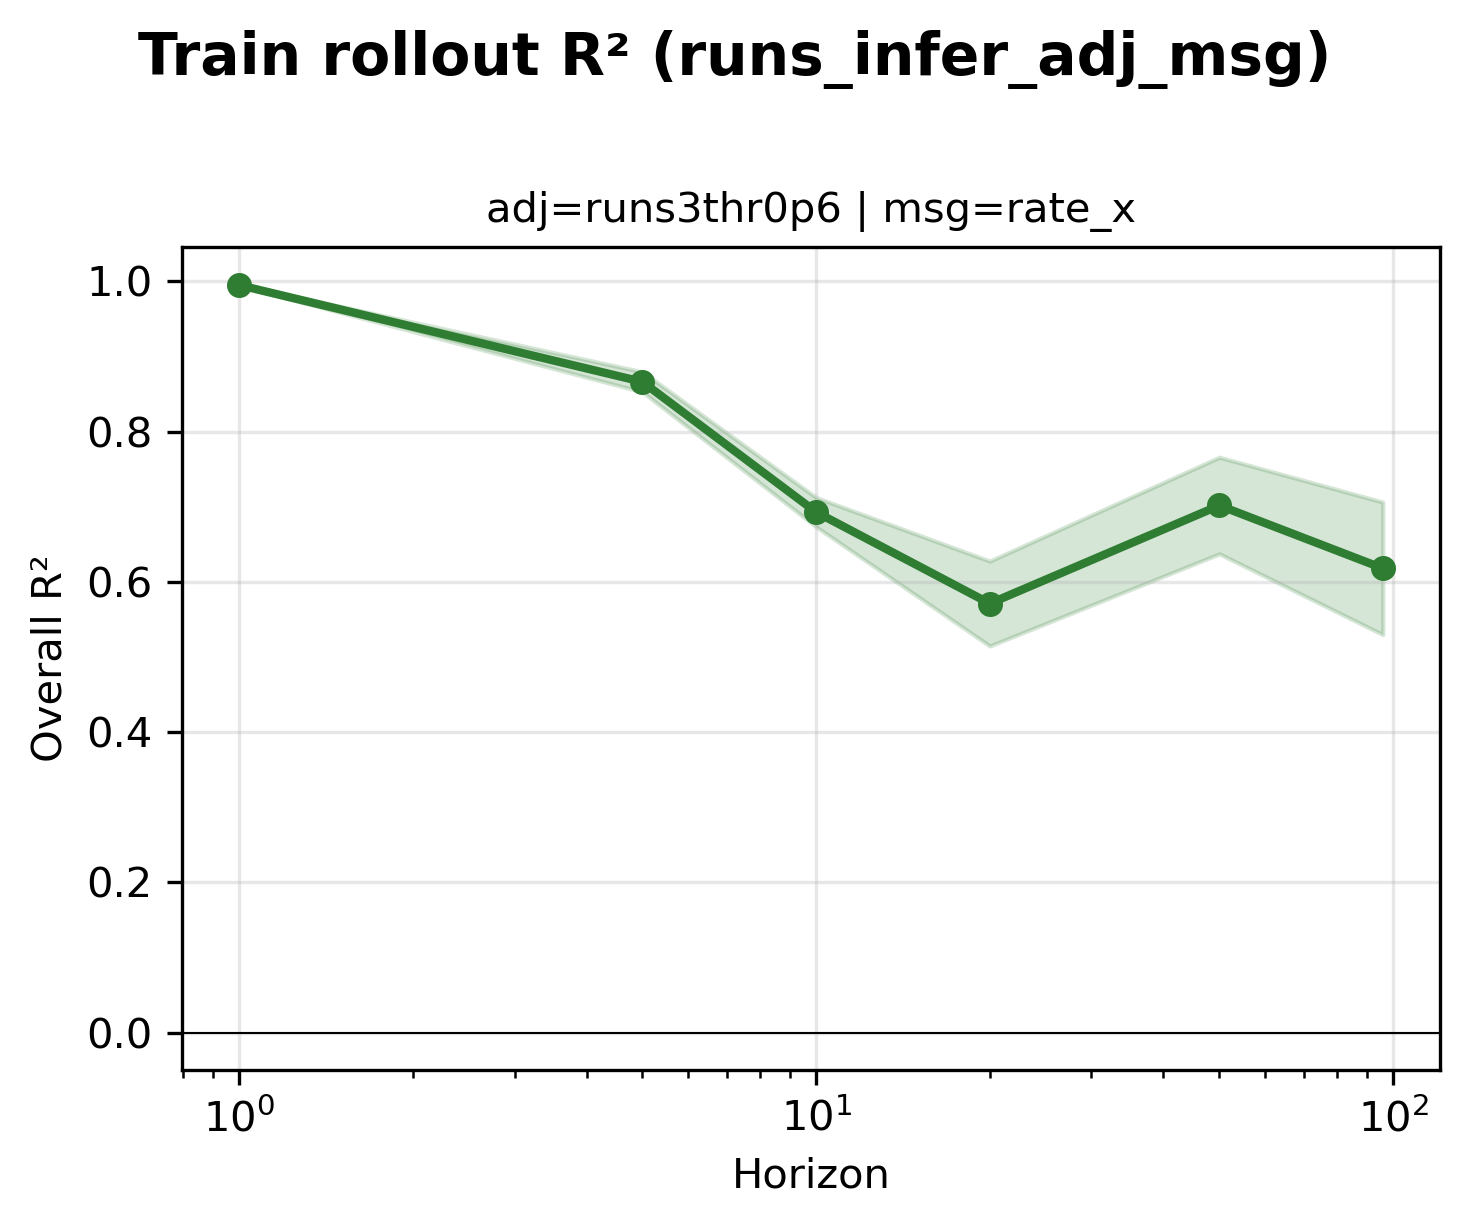

In [7]:
df_train = rollout_df[rollout_df['split'] == 'train'].copy()
fig, axes = plt.subplots(len(ADJ_TYPES), len(MSG_CONFIGS_LIST),
                          figsize=(5 * len(MSG_CONFIGS_LIST), 4 * len(ADJ_TYPES)),
                          squeeze=False, dpi=300)
for i, adj in enumerate(ADJ_TYPES):
    for j, msg in enumerate(MSG_CONFIGS_LIST):
        ax = axes[i][j]
        sub = df_train[(df_train['adj_type'] == adj) & (df_train['msg_config'] == msg)]
        if len(sub):
            agg = sub.groupby('horizon')['r2'].agg(['mean', 'std']).reset_index().sort_values('horizon')
            agg['std'] = agg['std'].fillna(0)
            ax.plot(agg['horizon'], agg['mean'], 'o-', color='#2E7D32', lw=2, ms=5)
            ax.fill_between(agg['horizon'], agg['mean'] - agg['std'], agg['mean'] + agg['std'],
                             alpha=0.2, color='#2E7D32')
        ax.set_xscale('log')
        ax.set_xlabel('Horizon'); ax.set_ylabel('Overall R²')
        ax.set_title(f'adj={adj} | msg={msg}', fontsize=10)
        ax.grid(alpha=0.3); ax.axhline(0, color='k', lw=0.5)
plt.suptitle('Train rollout R² (runs_infer_adj_msg)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig(os.path.join(RUNS_DIR, 'rollout_infer_adj_msg_train_overall.png'), dpi=150, bbox_inches='tight')
plt.show()

## Train and test rollout phase graph

In [8]:
PHASE_ADJ_TYPES = ['runs3thr0p6']
PHASE_MSG_CONFIGS = ['rate_x']
PHASE_SEED = 4
PHASE_NODES = [0, 5, 10, 15]
PHASE_NODES = [n for n in PHASE_NODES if n < N]
print(f'Phase plots: nodes={PHASE_NODES}, seed={PHASE_SEED}')

rollout_start = t_train_start_raw
rollout_steps = T_raw - rollout_start - 1
print(f'Rollout from t={rollout_start} for {rollout_steps} steps '
      f'(covers train + val + test, length {rollout_steps}/{T_raw}).')

phase_traj_cache = {}
for adj in PHASE_ADJ_TYPES:
    for msg in PHASE_MSG_CONFIGS:
        d = run_dir_for(PHASE_SEED, adj, msg)
        if not d.is_dir():
            print(f'  [skip] missing run dir: {d}')
            continue
        try:
            model, norm_stats, _ = load_infer_adj_model(d, msg, device)
        except Exception as e:
            print(f'  [skip] {adj}|{msg} seed{PHASE_SEED}: {e}')
            continue
        Xp, Xt = rollout_predict(
            model, X_smooth, seasonal_full, rollout_start, rollout_steps,
            edge_index, device, norm_stats,
        )
        phase_traj_cache[(adj, msg)] = (Xp.copy(), Xt.copy())
        del model
        torch.cuda.empty_cache()
        print(f'  done {adj} | {msg}: Xp shape {Xp.shape}')


Phase plots: nodes=[0, 5, 10, 15], seed=4
Rollout from t=11 for 473 steps (covers train + val + test, length 473/485).
  done runs3thr0p6 | rate_x: Xp shape (473, 20)


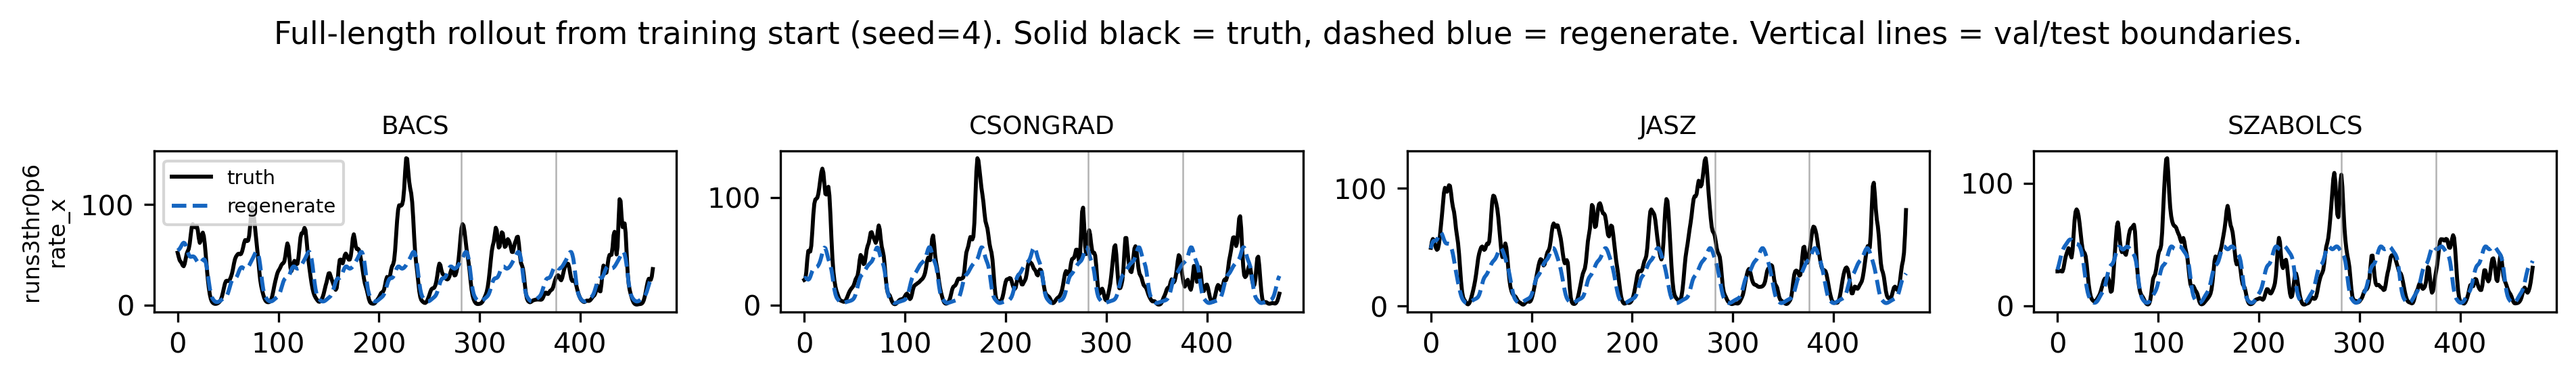

In [9]:
# ---- Plot 5 highlighted nodes per model in one 4x5 grid ------------
n_rows = len(PHASE_ADJ_TYPES) * len(PHASE_MSG_CONFIGS)
n_cols = len(PHASE_NODES)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 1.8 * n_rows),
                          squeeze=False, sharex=True, dpi=300)
row = 0
for adj in PHASE_ADJ_TYPES:
    for msg in PHASE_MSG_CONFIGS:
        Xp, Xt = phase_traj_cache.get((adj, msg), (None, None))
        for c, node in enumerate(PHASE_NODES):
            ax = axes[row][c]
            if Xp is not None:
                ax.plot(Xt[:, node], color='black', lw=1.4, label='truth')
                ax.plot(Xp[:, node], color='#1565C0', lw=1.4,
                        linestyle='--', label='regenerate')
                # mark train/val/test boundaries (in rollout-local indices)
                bnd_val   = max(0, n_train - 1)        # last train step
                bnd_test  = max(0, n_train + n_val - 1)
                for x_b, lbl in [(bnd_val, 'val'), (bnd_test, 'test')]:
                    if 0 < x_b < Xp.shape[0]:
                        ax.axvline(x_b, color='gray', lw=0.6, alpha=0.6)
            cname = county_names[node] if node < len(county_names) else f'node{node}'
            if row == 0:
                ax.set_title(cname, fontsize=9)
            if c == 0:
                ax.set_ylabel(f'{adj}\n{msg}', fontsize=8)
            # ax.grid(alpha=0.3)
            if row == 0 and c == 0:
                ax.legend(fontsize=7, loc='best')
        row += 1
fig.suptitle(
    f'Full-length rollout from training start (seed={PHASE_SEED}). '
    f'Solid black = truth, dashed blue = regenerate. '
    f'Vertical lines = val/test boundaries.',
    fontsize=11, y=1.01,
)
fig.tight_layout()
# fig.savefig(
#     os.path.join(RUNS_DIR, f'rollout_full_from_train_start_seed{PHASE_SEED}_nodes.png'),
#     dpi=150, bbox_inches='tight',
# )
plt.show()

Collected 5 seed rollouts, shape=(473, 20)


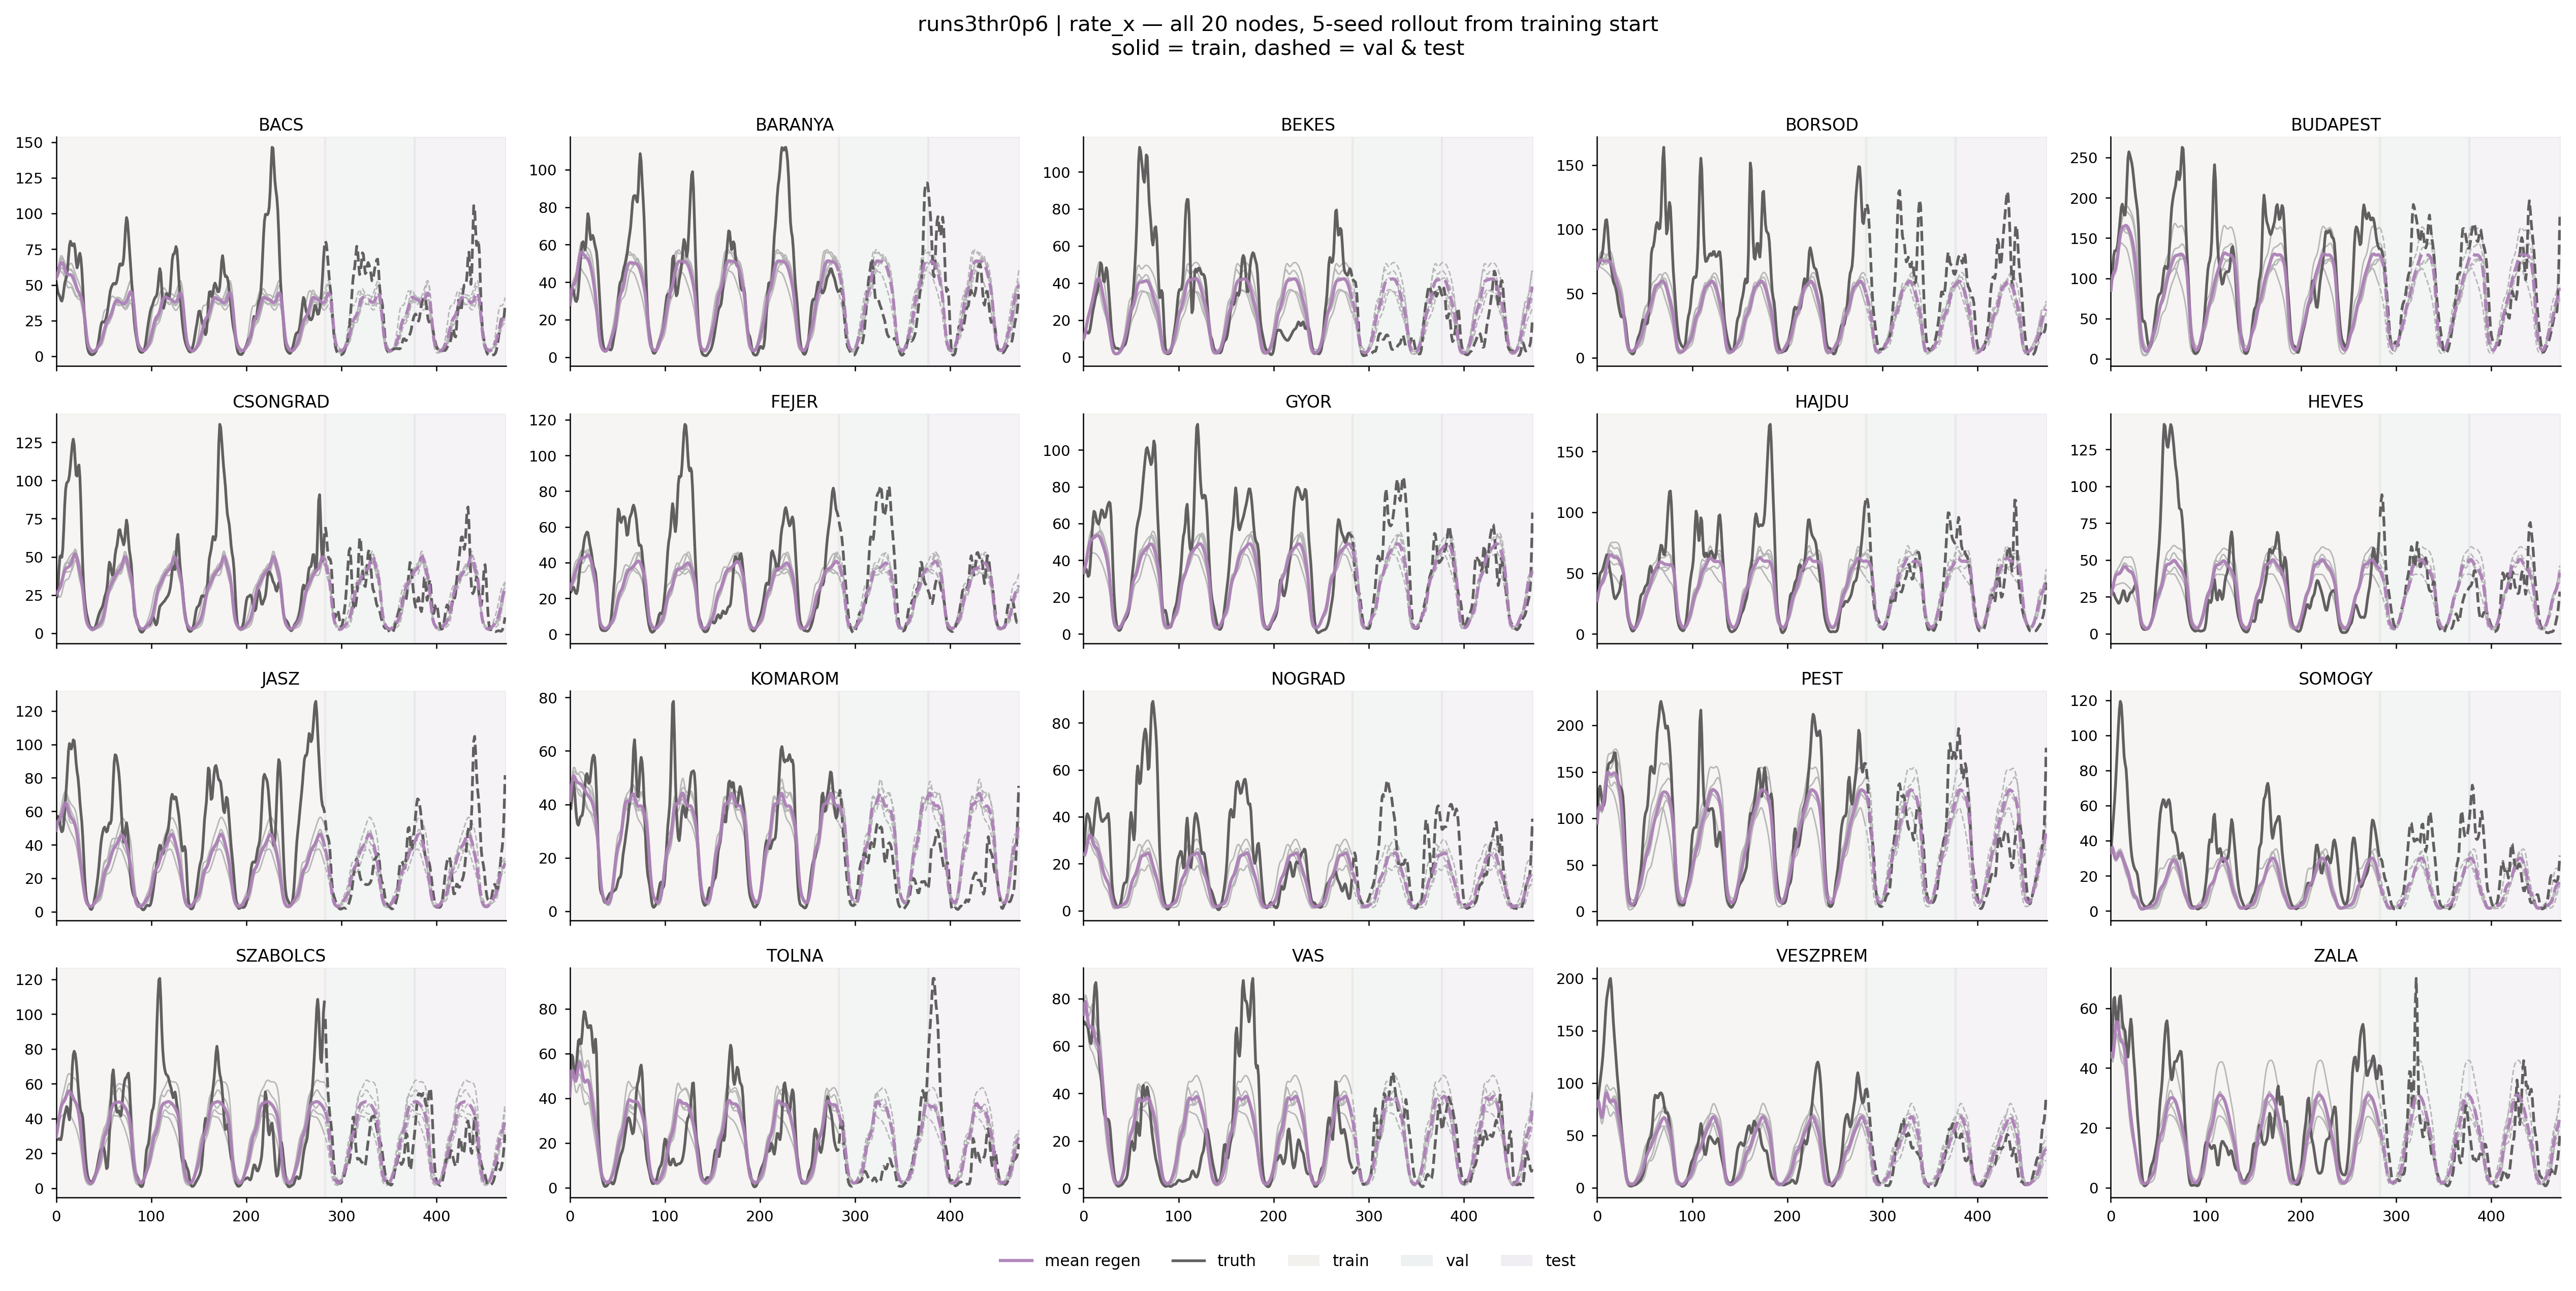

In [10]:
# ---- 20-node rollout for rate_x | runs3thr0p6, all 5 seeds -----------
PLOT_ADJ = 'runs3thr0p6'
PLOT_MSG = 'rate_x'
ALL_SEEDS = [1, 2, 3, 4, 5]
COLOR_MEAN  = '#AD81B7'
COLOR_SEED  = '#B5B5B6'
COLOR_TRUTH = '#595757'

# Background colours for train / val / test regions (low saturation, low alpha).
BG_TRAIN = '#E8E4DF'   # warm cream
BG_VAL   = '#DDE5E4'   # sage mist
BG_TEST  = '#E3DDE8'   # lavender haze
BG_ALPHA = 0.35

# Collect rollouts for every seed.
seed_trajs = []
for s in ALL_SEEDS:
    d = run_dir_for(s, PLOT_ADJ, PLOT_MSG)
    if not os.path.isdir(d):
        print(f'  [skip] missing {d}'); continue
    try:
        model, norm_stats, _ = load_infer_adj_model(d, PLOT_MSG, device)
    except Exception as e:
        print(f'  [skip] seed {s}: {e}'); continue
    Xp, Xt = rollout_predict(model, X_smooth, seasonal_full,
                              rollout_start, rollout_steps,
                              edge_index, device, norm_stats)
    seed_trajs.append(Xp.copy())
    del model; torch.cuda.empty_cache()
Xt_ref = Xt
print(f'Collected {len(seed_trajs)} seed rollouts, shape={seed_trajs[0].shape}')

stacked = np.stack(seed_trajs, axis=0)  # (n_seeds, T, N)
mean_traj = stacked.mean(axis=0)        # (T, N)
T_roll = mean_traj.shape[0]

bnd_train = n_train
bnd_test  = n_train + n_val

# 4 rows x 5 cols = 20 nodes.
n_rows_g, n_cols_g = 4, 5
fig, axes = plt.subplots(n_rows_g, n_cols_g,
                          figsize=(3.4 * n_cols_g, 2.0 * n_rows_g),
                          squeeze=False, sharex=True, dpi=300)

for idx in range(min(N, n_rows_g * n_cols_g)):
    r, c = divmod(idx, n_cols_g)
    ax = axes[r][c]

    # Background spans for train / val / test.
    ax.axvspan(0,         bnd_train, color=BG_TRAIN, alpha=BG_ALPHA, zorder=0)
    ax.axvspan(bnd_train, bnd_test,  color=BG_VAL,   alpha=BG_ALPHA, zorder=0)
    ax.axvspan(bnd_test,  T_roll,    color=BG_TEST,  alpha=BG_ALPHA, zorder=0)

    # Per-seed (light, dashed in val/test).
    for si in range(stacked.shape[0]):
        t = np.arange(T_roll)
        ax.plot(t[:bnd_train], stacked[si, :bnd_train, idx],
                color=COLOR_SEED, lw=0.7, ls='-', alpha=0.95, zorder=1)
        ax.plot(t[bnd_train:], stacked[si, bnd_train:, idx],
                color=COLOR_SEED, lw=0.7, ls='--', alpha=0.95, zorder=1)

    # Mean (purple).
    t = np.arange(T_roll)
    ax.plot(t[:bnd_train], mean_traj[:bnd_train, idx],
            color=COLOR_MEAN, lw=1.5, ls='-', alpha=0.95, zorder=3,
            label='mean regen' if idx == 0 else None)
    ax.plot(t[bnd_train:], mean_traj[bnd_train:, idx],
            color=COLOR_MEAN, lw=1.5, ls='--', alpha=0.95, zorder=3)

    # Ground truth.
    ax.plot(t[:bnd_train], Xt_ref[:bnd_train, idx],
            color=COLOR_TRUTH, lw=1.3, ls='-', alpha=0.95, zorder=2,
            label='truth' if idx == 0 else None)
    ax.plot(t[bnd_train:], Xt_ref[bnd_train:, idx],
            color=COLOR_TRUTH, lw=1.3, ls='--', alpha=0.95, zorder=2)

    cname = county_names[idx] if idx < len(county_names) else f'node{idx}'
    ax.set_title(cname, fontsize=8, pad=3)
    ax.set_xlim(0, T_roll)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.6)
    ax.spines['bottom'].set_linewidth(0.6)
    ax.tick_params(direction='out', length=2.5, width=0.6, labelsize=7)

# Hide unused axes.
for empty in range(min(N, n_rows_g * n_cols_g), n_rows_g * n_cols_g):
    r, c = divmod(empty, n_cols_g)
    axes[r][c].axis('off')

# Legend (data) from first subplot + manual patches for background.
from matplotlib.patches import Patch
bg_patches = [
    Patch(facecolor=BG_TRAIN, alpha=BG_ALPHA + 0.15, label='train'),
    Patch(facecolor=BG_VAL,   alpha=BG_ALPHA + 0.15, label='val'),
    Patch(facecolor=BG_TEST,  alpha=BG_ALPHA + 0.15, label='test'),
]
handles, labels = axes[0][0].get_legend_handles_labels()
handles += bg_patches
labels  += [p.get_label() for p in bg_patches]
fig.legend(handles, labels, loc='lower center', ncol=len(labels), fontsize=7.5,
           frameon=False, bbox_to_anchor=(0.5, -0.03))

fig.suptitle(
    f'{PLOT_ADJ} | {PLOT_MSG} — all 20 nodes, 5-seed rollout from training start\n'
    f'solid = train, dashed = val & test',
    fontsize=10, y=1.01)
fig.tight_layout()
# fig.savefig(str(RUNS_DIR /
#     f'Trainstart_rollout_allseeds_{PLOT_ADJ}_{PLOT_MSG}_20nodes.pdf'), dpi=300, bbox_inches='tight')
plt.show()


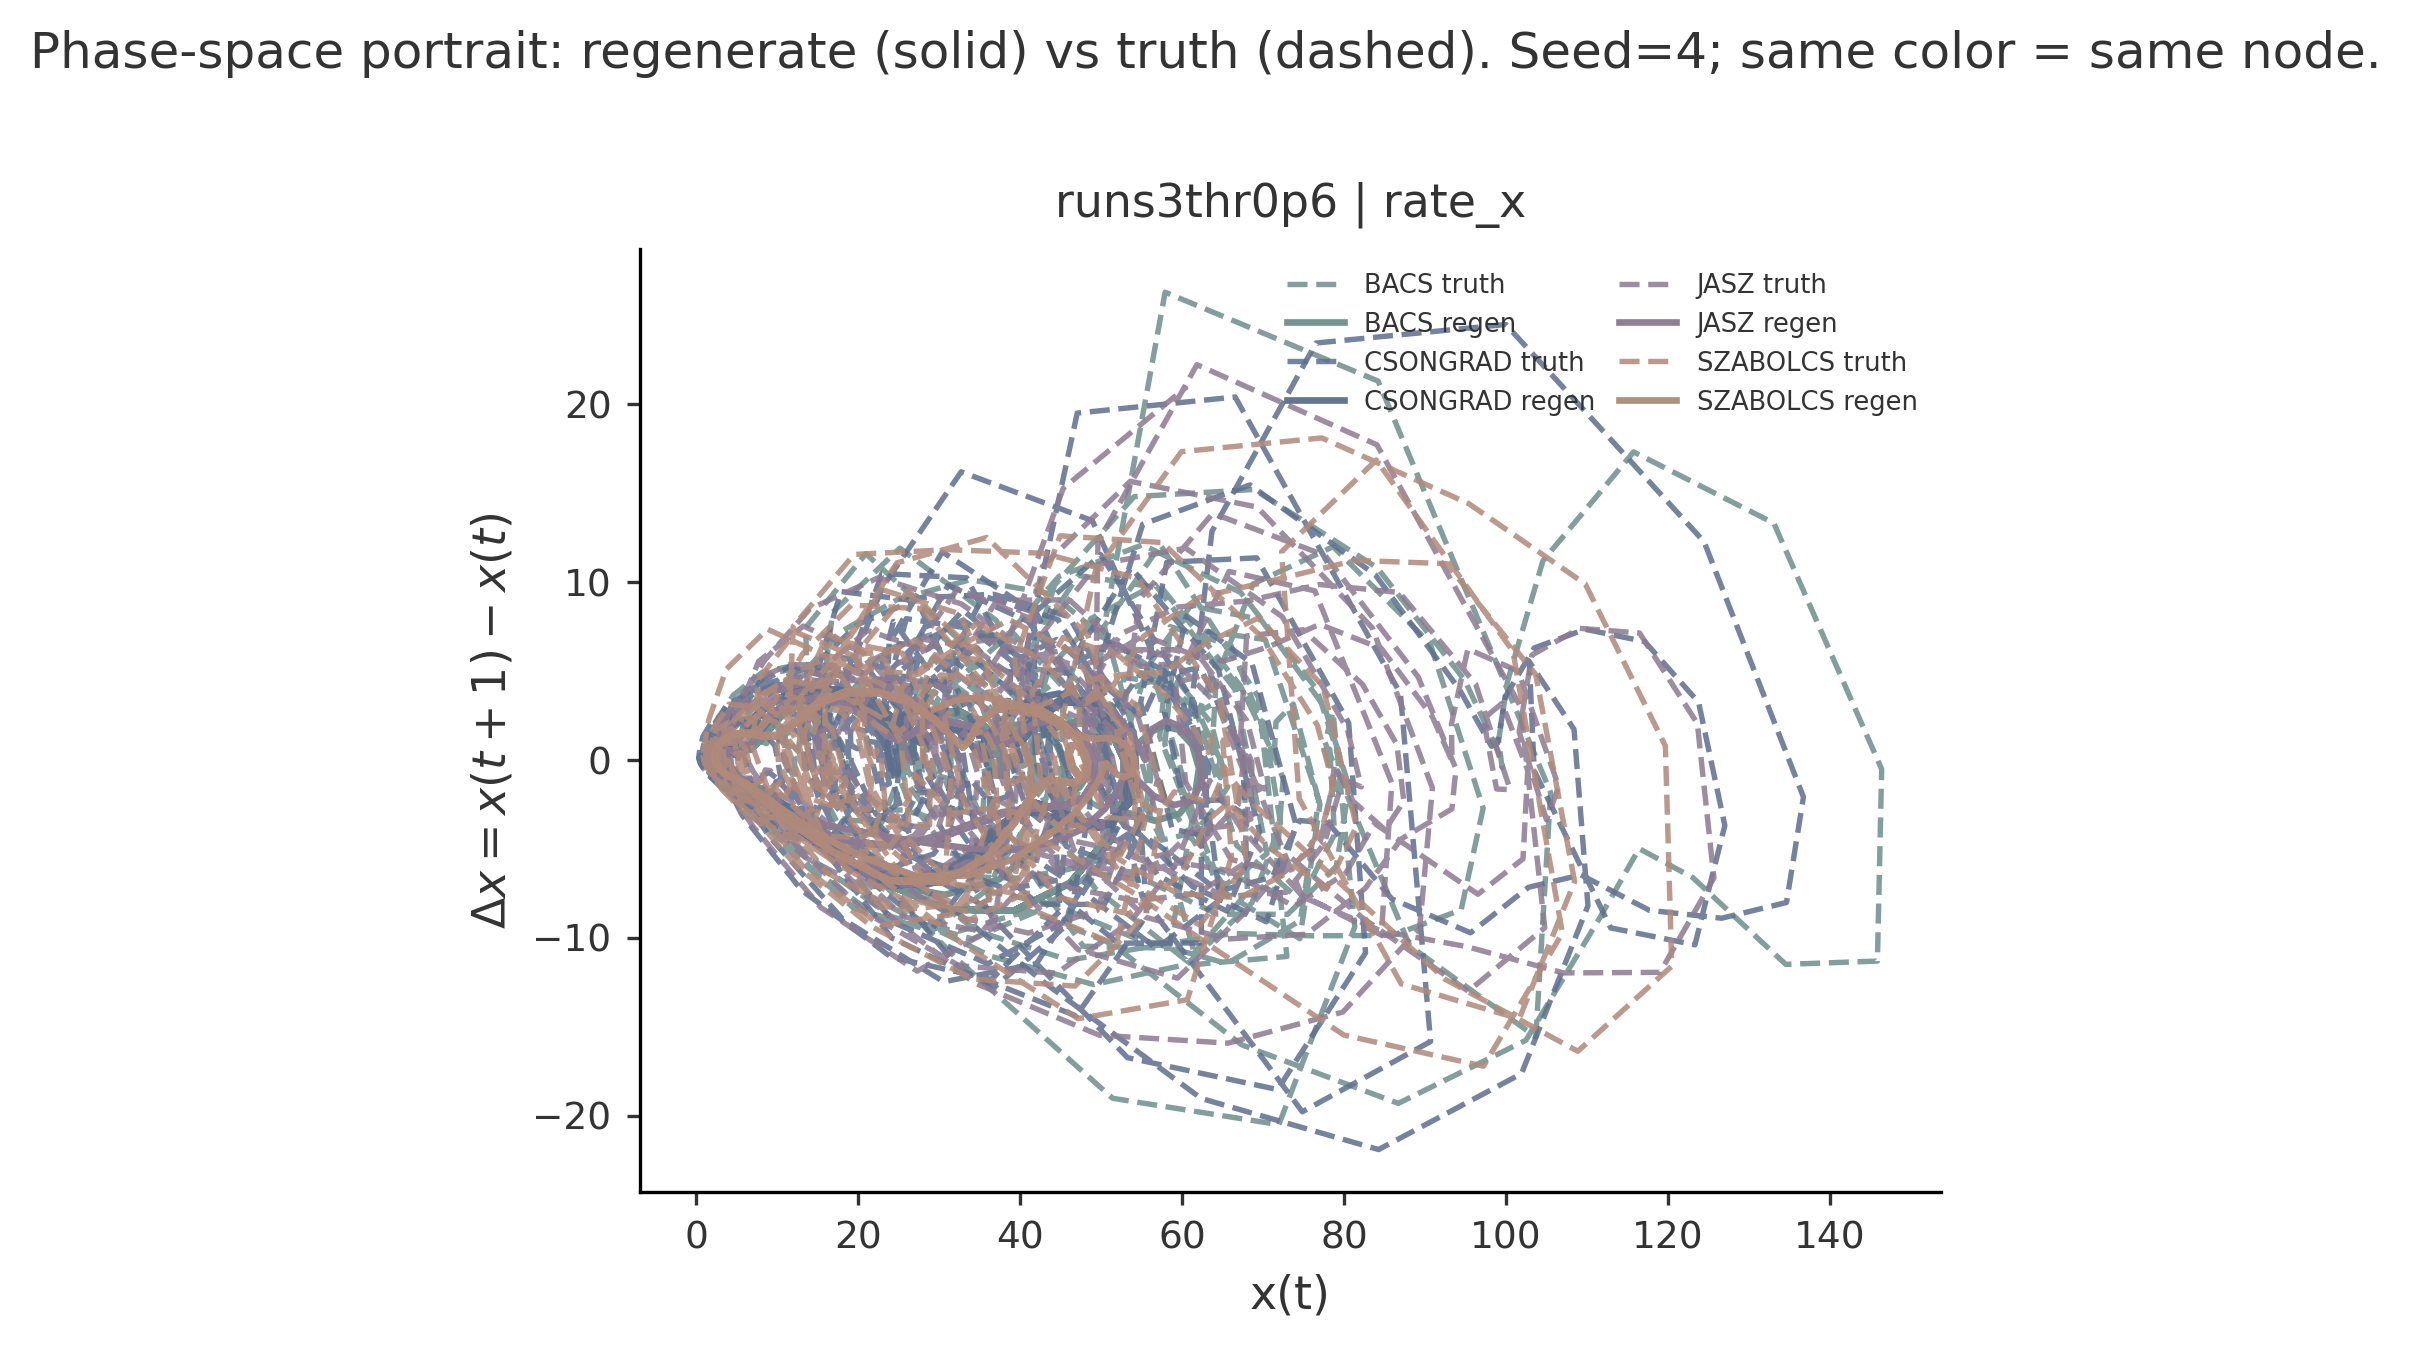

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---- Phase-space comparison: x vs dx for the 5 selected nodes ------
# One subplot per model. Within a subplot we overlay 5 nodes:
#   solid line = (regenerate x[t], regenerate dx[t])
#   dashed line = (true x[t],     true dx[t])
# dx is taken as the forward difference along the rollout / truth series.

def x_dx(traj):
    """Return (x[:-1], dx) where dx[t] = traj[t+1] - traj[t]."""
    if traj is None or len(traj) < 2:
        return None, None
    return traj[:-1], np.diff(traj, axis=0)

# Figure-5-like harmonious palette
FIG5_NODE_COLORS = [
    "#6F8F8D",  # sage teal
    "#5E6F8E",  # slate blue
    "#8D7A92",  # dusty mauve
    "#B08A7A",  # warm taupe
    "#7F97A8",  # soft blue-grey
]

TEXT_COLOR = "#333333"
AXIS_GREY  = "#8A8A8A"
GRID_GREY  = "#E9E6E2"

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "text.color": TEXT_COLOR,
    "axes.labelcolor": TEXT_COLOR,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
})

models = [('runs3thr0p6', 'rate_x')]
n_models = len(models)
n_cols2 = 1
n_rows2 = int(np.ceil(n_models / n_cols2))

fig, axes = plt.subplots(
    n_rows2, n_cols2,
    figsize=(5.2 * n_cols2, 4.4 * n_rows2),
    squeeze=False, dpi=300
)

# Use harmonious fixed palette instead of tab10
node_colors = FIG5_NODE_COLORS[:max(len(PHASE_NODES), 1)]
if len(PHASE_NODES) > len(FIG5_NODE_COLORS):
    # fallback: repeat if more than 5 nodes
    repeats = int(np.ceil(len(PHASE_NODES) / len(FIG5_NODE_COLORS)))
    node_colors = (FIG5_NODE_COLORS * repeats)[:len(PHASE_NODES)]

for m_i, (adj, msg) in enumerate(models):
    r, c = divmod(m_i, n_cols2)
    ax = axes[r][c]
    Xp, Xt = phase_traj_cache.get((adj, msg), (None, None))

    if Xp is None:
        ax.set_title(f'{adj} | {msg}  (no data)', fontsize=10)
        ax.axis('off')
        continue

    for n_i, node in enumerate(PHASE_NODES):
        col = node_colors[n_i]
        cname = county_names[node] if node < len(county_names) else f'node{node}'

        x_t, dx_t = x_dx(Xt[:, node])
        x_p, dx_p = x_dx(Xp[:, node])

        if x_t is None:
            continue

        # truth: dashed, slightly lighter
        ax.plot(x_t, dx_t, color=col, lw=1.3, linestyle='--', alpha=0.86, label=f'{cname} truth')

        # regenerate: solid, slightly stronger
        ax.plot(x_p, dx_p, color=col, lw=1.6, linestyle='-', alpha=0.96, label=f'{cname} regen')

    ax.set_title(f'{adj} | {msg}', fontsize=11, pad=8)
    ax.set_xlabel('x(t)')
    ax.set_ylabel(r'$\Delta x = x(t+1)-x(t)$')

    # ax.axhline(0, color=AXIS_GREY, lw=0.8, alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.tick_params(direction='out', length=3.2, width=0.8)

    ax.legend(fontsize=6.2, loc='best', ncol=2, frameon=False, handlelength=2.2, columnspacing=0.9)

# Hide any unused axes
for empty_idx in range(n_models, n_rows2 * n_cols2):
    r, c = divmod(empty_idx, n_cols2)
    axes[r][c].axis('off')

fig.suptitle(
    f'Phase-space portrait: regenerate (solid) vs truth (dashed). '
    f'Seed={PHASE_SEED}; same color = same node.',
    fontsize=12, y=1.01,
)
fig.tight_layout()

# fig.savefig(
#     os.path.join(RUNS_DIR, f'rollout_full_from_train_start_seed{PHASE_SEED}_phase.pdf'),
#     dpi=300, bbox_inches='tight',
# )
plt.show()

In [12]:
# # ---- Phase-space comparison: x vs dx for the 5 selected nodes ------
# # One subplot per model. Within a subplot we overlay 5 nodes:
# #   solid line = (regenerate x[t], regenerate dx[t])
# #   dashed line = (true x[t],     true dx[t])
# # dx is taken as the forward difference along the rollout / truth series.
# def x_dx(traj):
#     """Return (x[:-1], dx) where dx[t] = traj[t+1] - traj[t]."""
#     if traj is None or len(traj) < 2:
#         return None, None
#     return traj[:-1], np.diff(traj, axis=0)

# models = [('runs3thr0p6', 'rate_x')]
# n_models = len(models)
# n_cols2 = 2
# n_rows2 = int(np.ceil(n_models / n_cols2))
# fig, axes = plt.subplots(n_rows2, n_cols2, figsize=(5.2 * n_cols2, 4.4 * n_rows2),
#                           squeeze=False, dpi=300)
# node_colors = plt.cm.tab10(np.linspace(0, 1, max(len(PHASE_NODES), 1)))

# for m_i, (adj, msg) in enumerate(models):
#     r, c = divmod(m_i, n_cols2)
#     ax = axes[r][c]
#     Xp, Xt = phase_traj_cache.get((adj, msg), (None, None))
#     if Xp is None:
#         ax.set_title(f'{adj} | {msg}  (no data)', fontsize=10)
#         ax.axis('off')
#         continue
#     for n_i, node in enumerate(PHASE_NODES):
#         col = node_colors[n_i]
#         cname = county_names[node] if node < len(county_names) else f'node{node}'
#         x_t,  dx_t  = x_dx(Xt[:, node])
#         x_p,  dx_p  = x_dx(Xp[:, node])
#         if x_t is None:
#             continue
#         ax.plot(x_t, dx_t, color=col, lw=1.2, linestyle='--',
#                 alpha=0.9, label=f'{cname} truth')
#         ax.plot(x_p, dx_p, color=col, lw=1.2, linestyle='-',
#                 alpha=0.9, label=f'{cname} regen')
#     ax.set_title(f'{adj} | {msg}', fontsize=11)
#     ax.set_xlabel('x(t)')
#     ax.set_ylabel('dx/dt = x(t+1) - x(t)')
#     ax.axhline(0, color='k', lw=0.5, alpha=0.5)
#     ax.legend(fontsize=6, loc='best', ncol=2)

# # Hide any unused axes (e.g. if n_models doesn't fill the grid).
# for empty_idx in range(n_models, n_rows2 * n_cols2):
#     r, c = divmod(empty_idx, n_cols2)
#     axes[r][c].axis('off')

# fig.suptitle(
#     f'Phase-space portrait: regenerate (solid) vs truth (dashed). '
#     f'seed={PHASE_SEED}. Same color = same node.',
#     fontsize=12, y=1.01,
# )
# fig.tight_layout()
# # fig.savefig(
# #     str(RUNS_DIR / f'rollout_full_from_train_start_seed{PHASE_SEED}_phase.png'),
# #     dpi=150, bbox_inches='tight',
# # )
# plt.show()


## Summary table — full-horizon test rollout

In [12]:
full_h = df_test['horizon'].max()
full = df_test[df_test['horizon'] == full_h]
summary = (full.groupby(['adj_type', 'msg_config'])
                .agg(r2_mean=('r2', 'mean'), r2_std=('r2', 'std'),
                     node_r2_mean=('node_r2_mean', 'mean'),
                     mse_mean=('mse', 'mean'), n_seeds=('seed', 'nunique'))
                .reset_index())
summary = summary.sort_values(['adj_type', 'msg_config'])
summary.to_csv(RUNS_DIR / 'rollout_infer_adj_msg_summary.csv', index=False)
summary

,adj_type,msg_config,r2_mean,r2_std,node_r2_mean,mse_mean,n_seeds
0,runs3thr0p6,rate_x,0.622847,0.072009,0.215008,362.846027,5


## Example trajectories — full test rollout for a few counties
Each panel: rows are different (adj_type × msg_config) configs averaged over seeds (mean trajectory + per-seed lines), against ground truth on the test set.

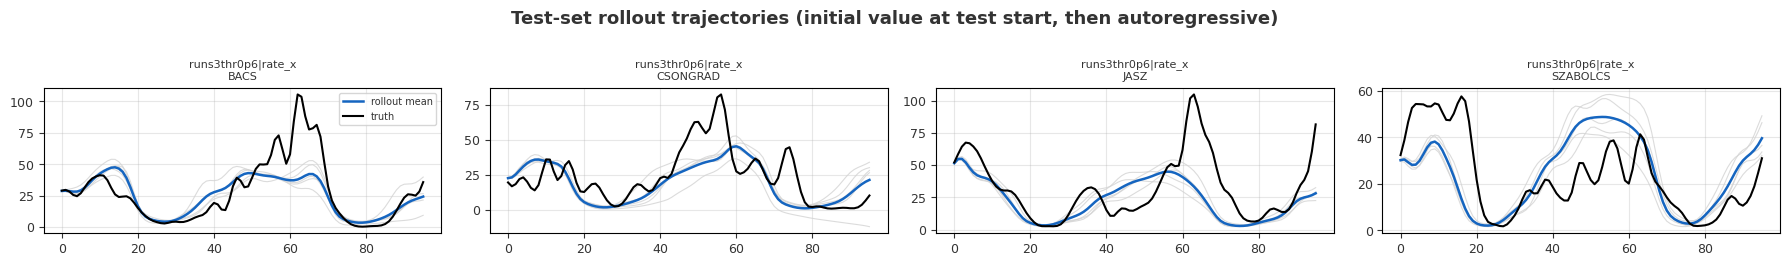

In [13]:
# Pick a handful of counties to visualize
node_idx_to_show = [0, 5, 10, 15]
node_idx_to_show = [i for i in node_idx_to_show if i < N]

configs = [('runs3thr0p6', 'rate_x')]
n_rows = len(configs); n_cols = len(node_idx_to_show)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 2.6 * n_rows), squeeze=False)
for r, (adj, msg) in enumerate(configs):
    seed_traj = []
    Xt_ref = None
    for s in SEEDS:
        key = (adj, msg, s)
        if key not in test_traj_cache: continue
        Xp, Xt = test_traj_cache[key]
        seed_traj.append(Xp); Xt_ref = Xt
    if Xt_ref is None: continue
    seed_traj = np.stack(seed_traj, axis=0)  # [seeds, T, N]
    mean_traj = seed_traj.mean(axis=0)
    for c, node in enumerate(node_idx_to_show):
        ax = axes[r][c]
        for s_i in range(seed_traj.shape[0]):
            ax.plot(seed_traj[s_i, :, node], color='lightgray', lw=0.8, alpha=0.8)
        ax.plot(mean_traj[:, node], color='#1565C0', lw=1.8, label='rollout mean')
        ax.plot(Xt_ref[:, node], color='black', lw=1.5, label='truth')
        title = f'{adj}|{msg}\n{county_names[node]}' if r == 0 else f'{adj}|{msg}'
        ax.set_title(title, fontsize=8)
        if r == 0 and c == 0:
            ax.legend(fontsize=7)
        ax.grid(alpha=0.3)
plt.suptitle('Test-set rollout trajectories (initial value at test start, then autoregressive)',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
# plt.savefig(str(RUNS_DIR / 'rollout_infer_adj_msg_test_trajectories.png'), dpi=150, bbox_inches='tight')
plt.show()

## Total trajectories — full test rollout for a all counties

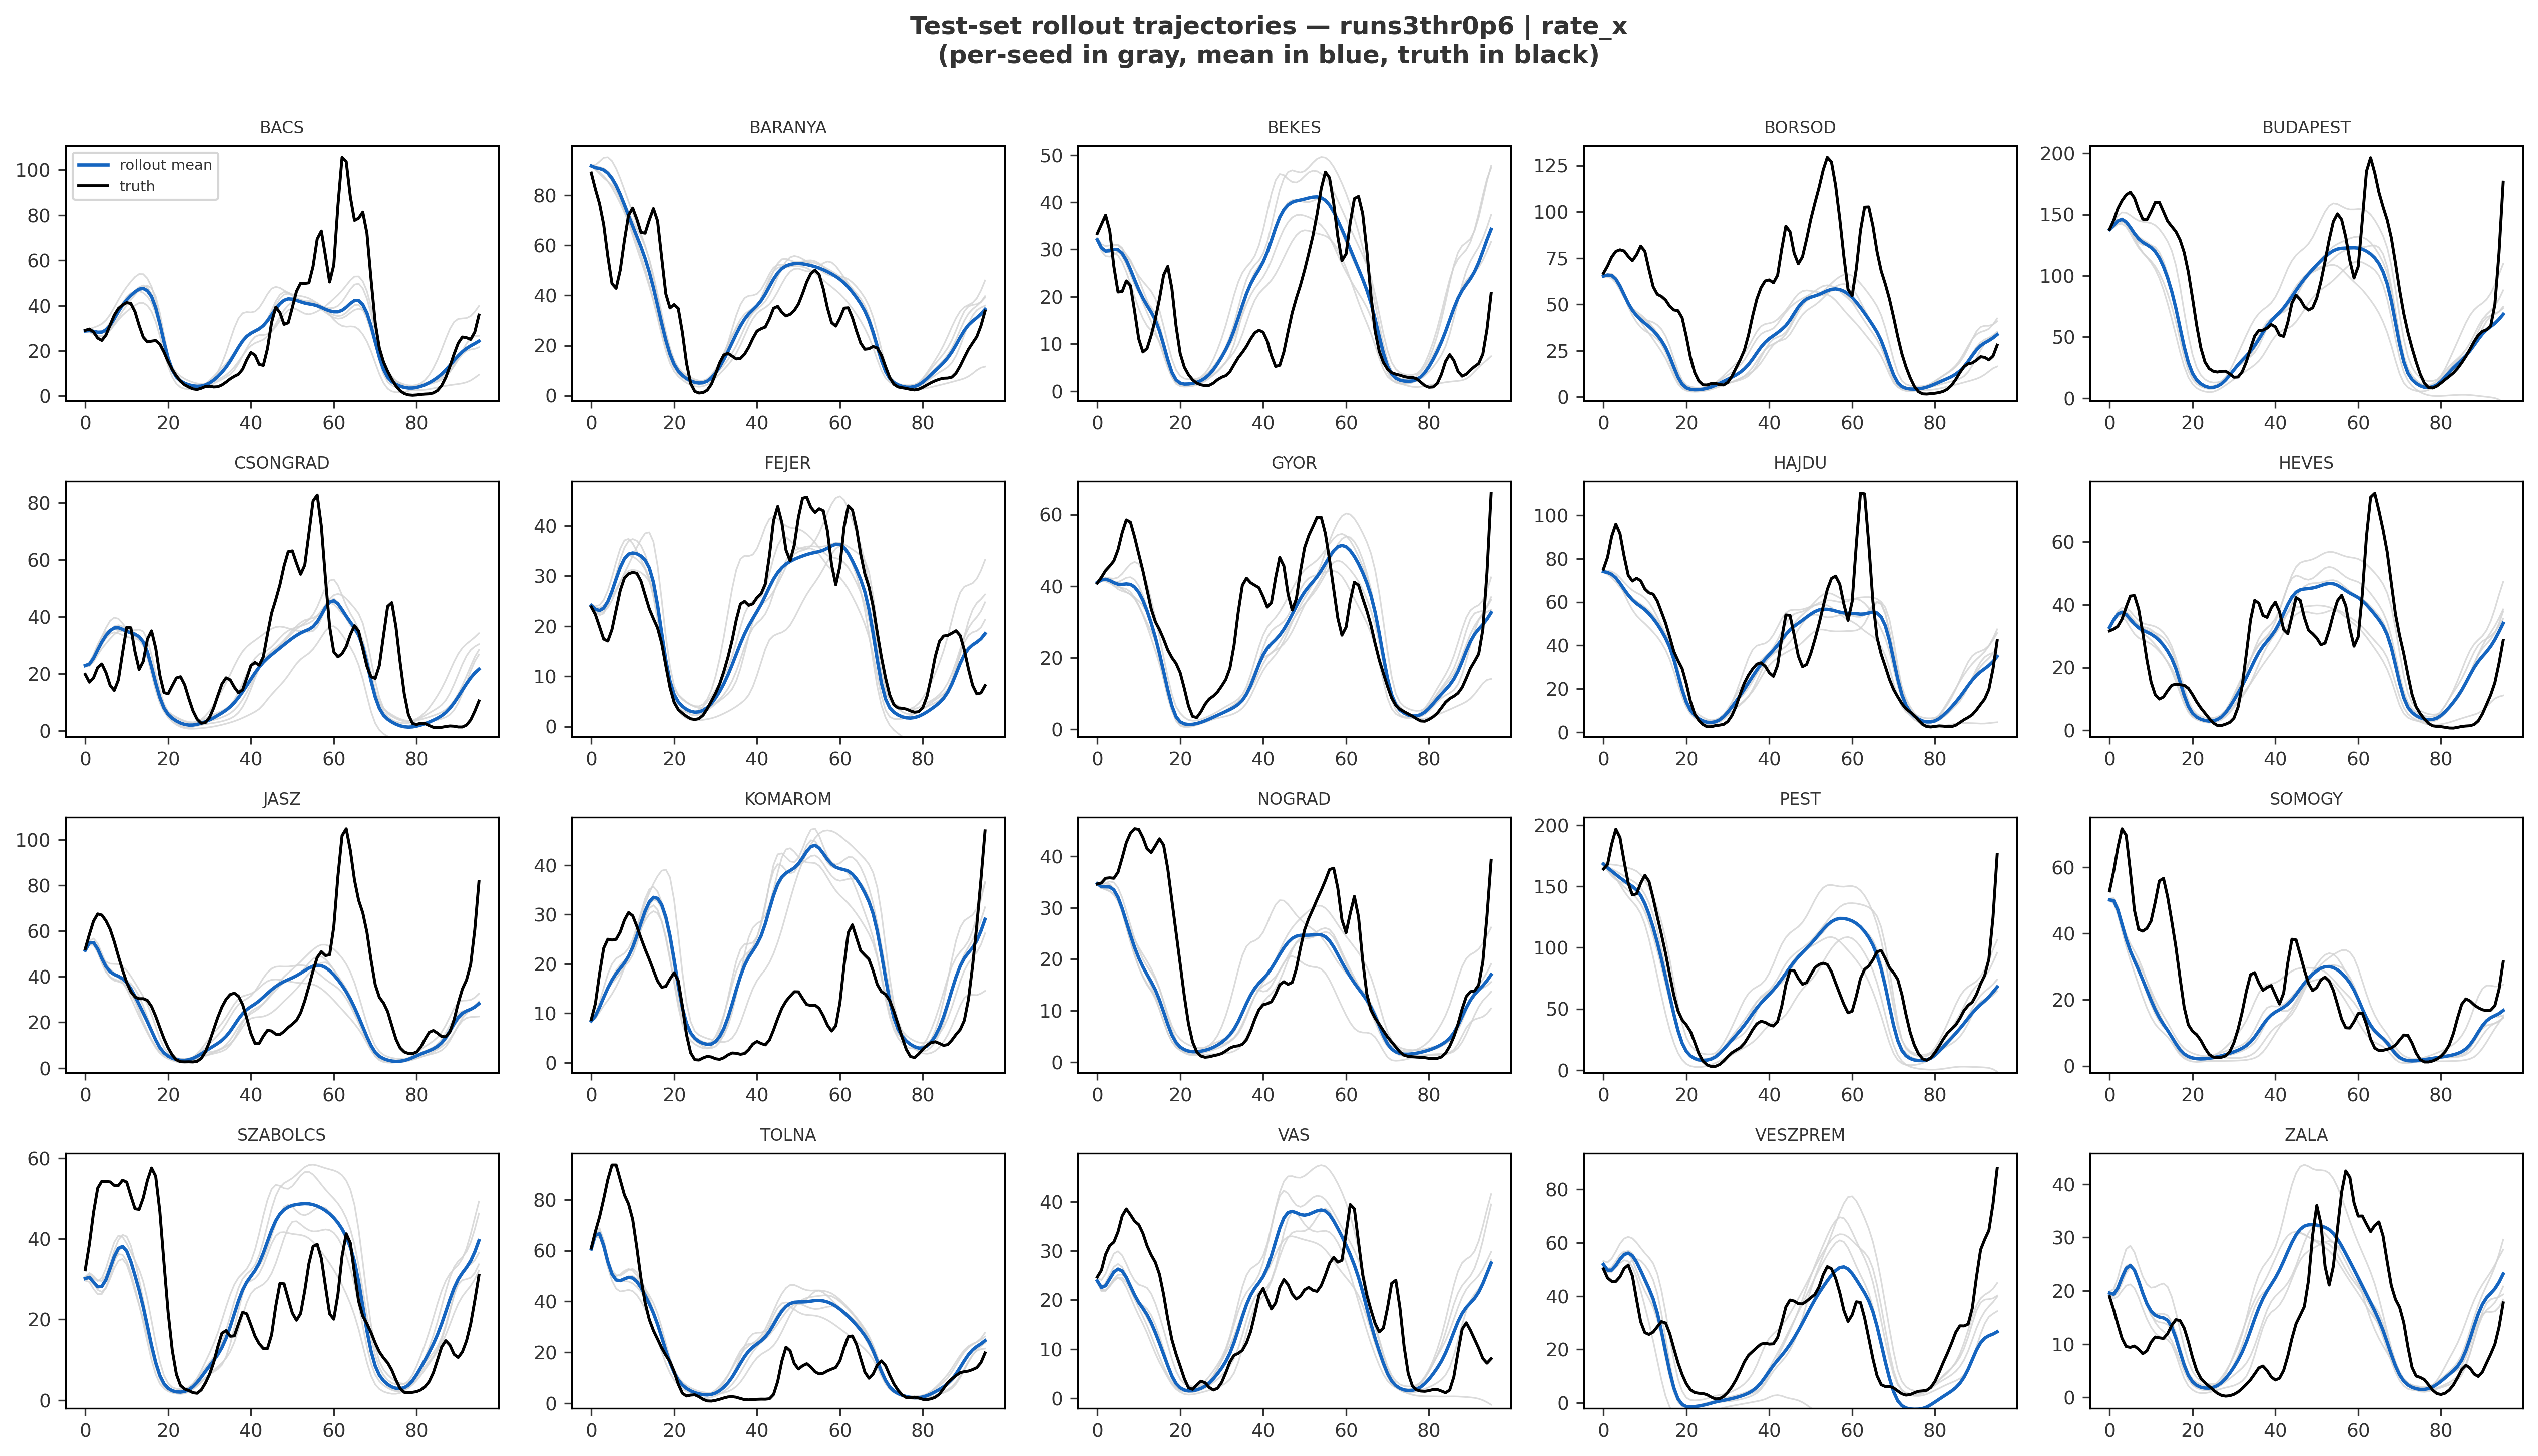

In [14]:
# One figure per (adj_type, msg_config) — 4x5 grid showing all 20 nodes.
# Same style as the previous plot: per-seed lines in light gray, mean across
# seeds in blue, ground truth in black. To get exactly N figures, restrict
# ADJ_TYPES / MSG_CONFIGS_LIST at the top of the notebook to the pairs you want.
n_rows_grid, n_cols_grid = 4, 5
nodes_per_fig = n_rows_grid * n_cols_grid

for adj in ADJ_TYPES:
    for msg in MSG_CONFIGS_LIST:
        seed_traj = []
        Xt_ref = None
        for s in SEEDS:
            key = (adj, msg, s)
            if key not in test_traj_cache:
                continue
            Xp, Xt = test_traj_cache[key]
            seed_traj.append(Xp)
            Xt_ref = Xt
        if Xt_ref is None or not seed_traj:
            print(f'[skip] no rollout data for {adj} | {msg}')
            continue

        seed_traj = np.stack(seed_traj, axis=0)        # [seeds, T, N]
        mean_traj = seed_traj.mean(axis=0)              # [T, N]
        n_nodes = Xt_ref.shape[1]
        nodes_to_show = list(range(min(n_nodes, nodes_per_fig)))

        fig, axes = plt.subplots(
            n_rows_grid, n_cols_grid,
            figsize=(3.4 * n_cols_grid, 2.4 * n_rows_grid),
            squeeze=False, dpi=300
        )
        for idx, node in enumerate(nodes_to_show):
            r, c = divmod(idx, n_cols_grid)
            ax = axes[r][c]
            for s_i in range(seed_traj.shape[0]):
                ax.plot(seed_traj[s_i, :, node], color='lightgray', lw=0.8, alpha=0.8)
            ax.plot(mean_traj[:, node], color='#1565C0', lw=1.6, label='rollout mean')
            ax.plot(Xt_ref[:, node], color='black', lw=1.4, label='truth')
            cname = county_names[node] if node < len(county_names) else f'node{node}'
            ax.set_title(cname, fontsize=8)
            ax.set_ylim(bottom=-2)
            # ax.grid(alpha=0.3)
            if idx == 0:
                ax.legend(fontsize=7, loc='best')
        # Blank out any leftover axes if n_nodes < nodes_per_fig.
        for empty_idx in range(len(nodes_to_show), n_rows_grid * n_cols_grid):
            r, c = divmod(empty_idx, n_cols_grid)
            axes[r][c].axis('off')

        fig.suptitle(
            f'Test-set rollout trajectories — {adj} | {msg}\n'
            f'(per-seed in gray, mean in blue, truth in black)',
            fontsize=12, fontweight='bold', y=1.005,
        )
        fig.tight_layout()
        # fig.savefig(
        #     os.path.join(
        #         RUNS_DIR,
        #         f'rollout_infer_adj_msg_test_trajectories_{adj}_{msg}_allnodes.pdf',
        #     ),
        #     dpi=300, bbox_inches='tight',
        # )
        plt.show()
